# Random Walk Simulation (Normalized Steps)

Each step is normalized to unit length using a scaling factor $L$:

$$\Delta x = \frac{1}{L} \Delta x', \quad \Delta y = \frac{1}{L} \Delta y'$$

where $\Delta x', \Delta y' \in [-1, 1]$ and $L = \sqrt{(\Delta x')^2 + (\Delta y')^2}$.

This ensures every step has exactly length 1, regardless of the random direction.

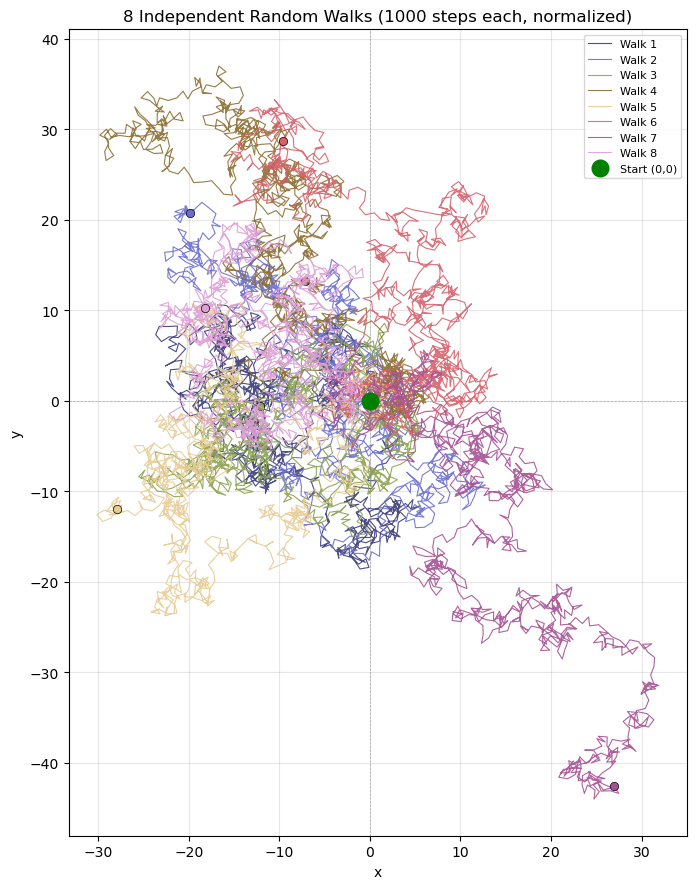

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(None)  # Seed generator, None => system clock

num_walks = 8      # Number of independent walks
jmax = 1000        # Number of steps per walk
a = 1
# High-contrast color palette for each walk
colors = plt.cm.tab20b(np.linspace(0, 1, num_walks))

fig, ax = plt.subplots(figsize=(9, 9))

for w in range(num_walks):
    x = 0.0; y = 0.0  # Each walk starts at origin
    xpositions = [x]
    ypositions = [y]

    for i in range(jmax):
        # Generate random displacements in [-1, 1]
        dx_prime = (random.random() - 0.5) * 2.0  # -1 <= dx' <= 1
        dy_prime = (random.random() - 0.5) * 2.0  # -1 <= dy' <= 1

        # Compute scaling factor L
        L = np.sqrt(dx_prime**2 + dy_prime**2)

        # Avoid division by zero (extremely unlikely but safe)
        if L == 0:
            continue

        # Normalize to unit step length
        dx = a * dx_prime / L  # delta_x = (1/L) * delta_x'
        dy = a * dy_prime / L  # delta_y = (1/L) * delta_y'

        x += dx
        y += dy
        xpositions.append(x)
        ypositions.append(y)

    # Plot each walk with a different color
    ax.plot(xpositions, ypositions, '-', color=colors[w], linewidth=0.8,
            alpha=0.9, label=f'Walk {w+1}')
    ax.plot(xpositions[-1], ypositions[-1], 'o', color=colors[w],
            markersize=6, markeredgecolor='black', markeredgewidth=0.5)  # End point

# Mark the shared start at the origin
ax.plot(0, 0, 'go', markersize=12, label='Start (0,0)', zorder=5)

# Draw crosshairs at the origin
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

ax.set_title(f'{num_walks} Independent Random Walks ({jmax} steps each, normalized)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='best', fontsize=8)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### JC: After many iterations the walks spread randomly outward in no particular direction. Although curiously even though its many steps its displacement is much less than the total distance traveled, this could be attributed that it is fundamentally random in any direction, so its more likely to go in a direction opposite from the previous walk.

Running 50 independent trials with 2500 steps each

Statistics from 50 trials:
Mean final displacement: 43.9447
Variance: 602.5553
Standard deviation: 24.5470
Min displacement: 6.7521
Max displacement: 94.7776


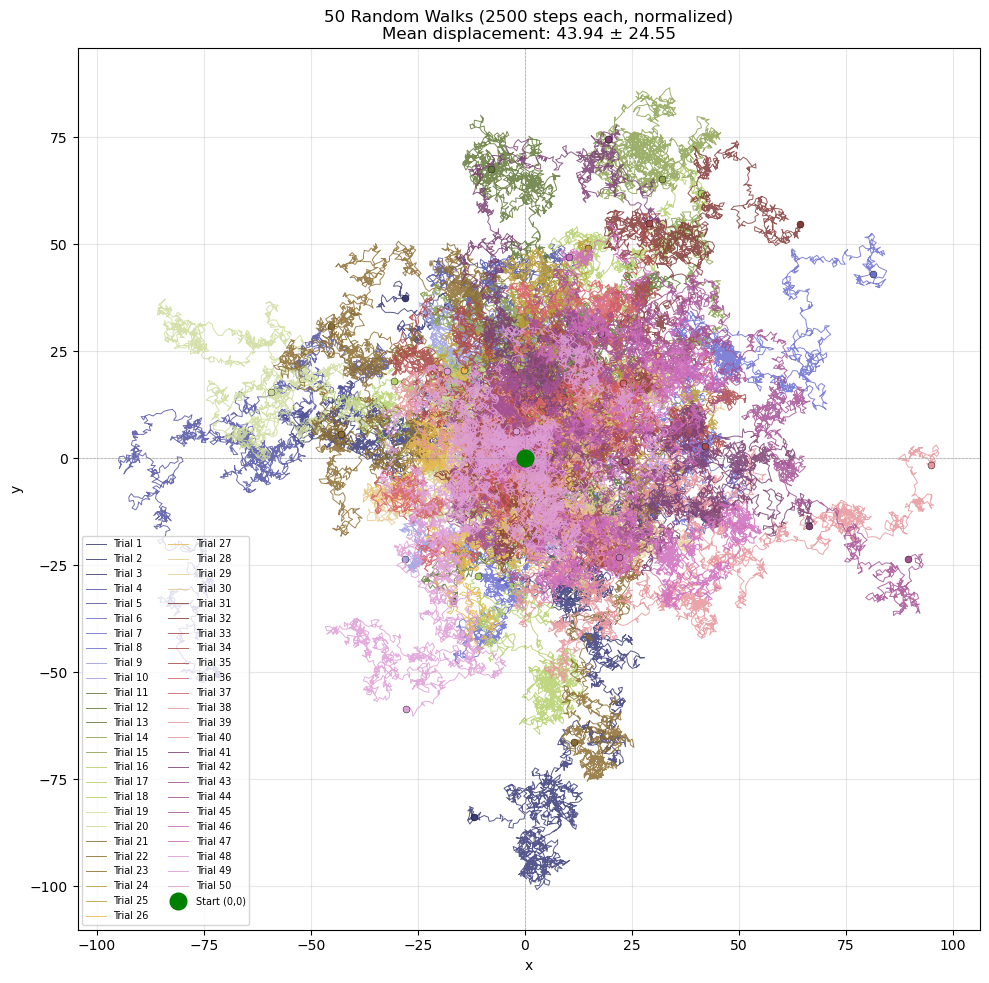

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import random

N = 2500        # Number of steps per walk
K = int(np.sqrt(N))  # Number of trials

# Store final displacements and full trajectories for each trial
final_displacements = []
trajectories = []

print(f"Running {K} independent trials with {N} steps each\n")

for trial in range(K):
    random.seed()  # Initialize with different seed for each trial
    
    x = 0.0; y = 0.0
    xpositions = [x]
    ypositions = [y]
    
    for step in range(N):
        # Generate random displacements in [-1, 1]
        dx_prime = (random.random() - 0.5) * 2.0
        dy_prime = (random.random() - 0.5) * 2.0
        
        # Compute scaling factor L
        L = np.sqrt(dx_prime**2 + dy_prime**2)
        
        if L == 0:
            continue
        
        # Normalize to unit step length
        dx = dx_prime / L
        dy = dy_prime / L
        
        x += dx
        y += dy
        xpositions.append(x)
        ypositions.append(y)
    
    # Store final displacement (distance from origin)
    final_displacement = np.sqrt(x**2 + y**2)
    final_displacements.append(final_displacement)
    
    # Store full trajectory
    trajectories.append((xpositions, ypositions))

# Compute statistics
final_displacements = np.array(final_displacements)
mean_displacement = np.mean(final_displacements)
variance_displacement = np.var(final_displacements)
std_displacement = np.std(final_displacements)

print(f"Statistics from {K} trials:")
print(f"Mean final displacement: {mean_displacement:.4f}")
print(f"Variance: {variance_displacement:.4f}")
print(f"Standard deviation: {std_displacement:.4f}")
print(f"Min displacement: {np.min(final_displacements):.4f}")
print(f"Max displacement: {np.max(final_displacements):.4f}")

# Visualize all trajectories with high-contrast colors
colors = plt.cm.tab20b(np.linspace(0, 1, K))

fig, ax = plt.subplots(figsize=(10, 10))

for trial in range(K):
    xpositions, ypositions = trajectories[trial]
    ax.plot(xpositions, ypositions, '-', color=colors[trial], linewidth=0.7,
            alpha=0.85, label=f'Trial {trial+1}')
    # Mark end point
    ax.plot(xpositions[-1], ypositions[-1], 'o', color=colors[trial],
            markersize=5, markeredgecolor='black', markeredgewidth=0.3)

# Mark the shared start at the origin
ax.plot(0, 0, 'go', markersize=12, label='Start (0,0)', zorder=5)

# Draw crosshairs at the origin
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.6)

ax.set_title(f'{K} Random Walks ({N} steps each, normalized)\nMean displacement: {mean_displacement:.2f} ± {std_displacement:.2f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='best', fontsize=7, ncol=2)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

JC: This output is what i asked for, trials is the square root of my number of walks. and each walk has a different seed due to the fact that each trial has a varying path. also i noticed originally the paths were hard to see so i asked it to change the path colors to contrast it

In [51]:
import numpy as np

trial_trajectories = trajectories
K_current = len(trial_trajectories)
R2_values = []

for trial_idx in range(K_current):
    xpositions, ypositions = trial_trajectories[trial_idx]
    x_end = xpositions[-1]
    y_end = ypositions[-1]

    #squared distance from origin for this trial: R^2 = x^2 + y^2
    R2 = x_end**2 + y_end**2
    R2_values.append(R2)

R2_values = np.array(R2_values)
avg_R2 = np.mean(R2_values) # Mean square distance for this trial (from origin): R^2 = x^2 + y^2

print(f'Using data source: {source_name}')
print(f'Number of trials K = {K_current}\n')
print('R^2 for each trial:')
for trial_idx, R2 in enumerate(R2_values, start=1):
    print(f'Trial {trial_idx:>2}: R^2 = {R2:.6f}')

print(f'\nAverage over all trials: <R^2> = {avg_R2:.6f}')

Using data source: normalized random walks
Number of trials K = 50

R^2 for each trial:
Trial  1: R^2 = 2187.959935
Trial  2: R^2 = 245.866377
Trial  3: R^2 = 7165.171003
Trial  4: R^2 = 711.666918
Trial  5: R^2 = 7664.519527
Trial  6: R^2 = 8455.103634
Trial  7: R^2 = 656.618309
Trial  8: R^2 = 680.367261
Trial  9: R^2 = 1348.482520
Trial 10: R^2 = 399.052699
Trial 11: R^2 = 4631.222414
Trial 12: R^2 = 746.456619
Trial 13: R^2 = 1394.756528
Trial 14: R^2 = 1774.808517
Trial 15: R^2 = 5270.234694
Trial 16: R^2 = 873.398626
Trial 17: R^2 = 1256.834805
Trial 18: R^2 = 5538.739324
Trial 19: R^2 = 136.983921
Trial 20: R^2 = 3762.244046
Trial 21: R^2 = 4532.562924
Trial 22: R^2 = 3001.003106
Trial 23: R^2 = 1885.429340
Trial 24: R^2 = 905.107001
Trial 25: R^2 = 2633.056820
Trial 26: R^2 = 93.818909
Trial 27: R^2 = 625.007382
Trial 28: R^2 = 1524.838020
Trial 29: R^2 = 360.436276
Trial 30: R^2 = 662.644472
Trial 31: R^2 = 106.171383
Trial 32: R^2 = 7118.761438
Trial 33: R^2 = 525.912414
Tria

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Single large random walk for precise calculation
N_large = 10000  # Large number of steps

print(f"Running single random walk with N = {N_large} steps")
print("=" * 70)

random.seed()
x = 0.0
y = 0.0
xpositions = [x]
ypositions = [y]

for step in range(N_large):
    # Generate random displacements in [-1, 1]
    dx_prime = (random.random() - 0.5) * 2.0
    dy_prime = (random.random() - 0.5) * 2.0
    
    # Compute scaling factor L
    L = np.sqrt(dx_prime**2 + dy_prime**2)
    
    if L == 0:
        continue
    
    # Normalize to unit step length
    dx = dx_prime / L
    dy = dy_prime / L
    
    x += dx
    y += dy
    xpositions.append(x)
    ypositions.append(y)

# Extract step increments
dx_steps = np.diff(xpositions)
dy_steps = np.diff(ypositions)

# Final position and R²
x_end = xpositions[-1]
y_end = ypositions[-1]
R2 = x_end**2 + y_end**2

N_actual = len(dx_steps)
print(f"Actual number of steps: {N_actual}")
print(f"Final position: ({x_end:.4f}, {y_end:.4f})")
print(f"R² = {R2:.4f}\n")

# Calculate exact mean of pairwise products
print("Calculating exact correlations...")
print("=" * 70)

# Method 1: Using the identity for cross-step correlation
# Σ_{i≠j} (Δx_i · Δx_j) = (Σ Δx_i)² - Σ (Δx_i)²
sum_dx = np.sum(dx_steps)
sum_dy = np.sum(dy_steps)
sum_dx_squared = np.sum(dx_steps**2)
sum_dy_squared = np.sum(dy_steps**2)

# Total sum of cross-products (excluding diagonal)
cross_sum_x = sum_dx**2 - sum_dx_squared
cross_sum_y = sum_dy**2 - sum_dy_squared

# Number of off-diagonal pairs
num_pairs = N_actual * (N_actual - 1)

# Mean of cross-step correlations
mean_cross_x = cross_sum_x / num_pairs
mean_cross_y = cross_sum_y / num_pairs

# Now divide by R²
mean_cross_x_normalized = mean_cross_x / R2
mean_cross_y_normalized = mean_cross_y / R2

print(f"1. Cross-step correlation (x): Mean[Δx_i · Δx_j (j≠i)] / R²")
print(f"   Mean of pairwise products: {mean_cross_x:.6f}")
print(f"   Divided by R²: {mean_cross_x_normalized:.6f}")

print(f"\n2. Cross-step correlation (y): Mean[Δy_i · Δy_j (j≠i)] / R²")
print(f"   Mean of pairwise products: {mean_cross_y:.6f}")
print(f"   Divided by R²: {mean_cross_y_normalized:.6f}")

# Same-step xy correlation
sum_dx_dy = np.sum(dx_steps * dy_steps)
mean_dx_dy = sum_dx_dy / N_actual
mean_dx_dy_normalized = mean_dx_dy / R2

print(f"\n3. Same-step xy correlation: Mean[Δx_i · Δy_i] / R²")
print(f"   Mean of products: {mean_dx_dy:.6f}")
print(f"   Divided by R²: {mean_dx_dy_normalized:.6f}")

print("\n" + "=" * 70)
print("VALIDATION RESULTS:")
print("=" * 70)

threshold = 0.01

if abs(mean_cross_x_normalized) < threshold:
    print(f"✓ Cross-step x correlation ≈ 0 ({mean_cross_x_normalized:.6f})")
else:
    print(f"✗ Cross-step x correlation = {mean_cross_x_normalized:.6f} (NOT ≈ 0)")

if abs(mean_cross_y_normalized) < threshold:
    print(f"✓ Cross-step y correlation ≈ 0 ({mean_cross_y_normalized:.6f})")
else:
    print(f"✗ Cross-step y correlation = {mean_cross_y_normalized:.6f} (NOT ≈ 0)")
    
if abs(mean_dx_dy_normalized) < threshold:
    print(f"✓ Same-step xy correlation ≈ 0 ({mean_dx_dy_normalized:.6f})")
else:
    print(f"✗ Same-step xy correlation = {mean_dx_dy_normalized:.6f} (NOT ≈ 0)")

print("=" * 70)

Running single random walk with N = 10000 steps
Actual number of steps: 10000
Final position: (-8.4774, -70.9251)
R² = 5102.2339

Calculating exact correlations...
1. Cross-step correlation (x): Mean[Δx_i · Δx_j (j≠i)] / R²
   Mean of pairwise products: -0.000050
   Divided by R²: -0.000000

2. Cross-step correlation (y): Mean[Δy_i · Δy_j (j≠i)] / R²
   Mean of pairwise products: 0.000001
   Divided by R²: 0.000000

3. Same-step xy correlation: Mean[Δx_i · Δy_i] / R²
   Mean of products: -0.000016
   Divided by R²: -0.000000

VALIDATION RESULTS:
✓ Cross-step x correlation ≈ 0 (-0.000000)
✓ Cross-step y correlation ≈ 0 (0.000000)
✓ Same-step xy correlation ≈ 0 (-0.000000)


### JC: For large steps (N) this shows there is no correlation, verifying that this is a true random walk. The reasoning is that if we average out the cross steps that cross each other it should equal to zero because no step should influence the other. I had to do more digging around to find out what cross steps were, and they come from the expansion of x^2. We should get a first sum that only sums the difference in x_i steps which is the normal distance. But the second sum is the tricky one where we get the sum of the differences of x_i and x_j!=i. This thoroughly confused me but I found out that statistically if you multiply a step in x by another step in x besides itself, it would statistically cancel each other out by law of averages in large numbers, kind of like how a large stellar body wouldn't typically have any charge because there are so many particles that they would even out.

In [53]:
import numpy as np

# Validate random walk assumptions using K trials with exact mean calculation
cross_step_x_correlations = []
cross_step_y_correlations = []
same_step_xy_correlations = []

print(f"Analyzing {K_current} trials with {N} steps each")
print("Using exact mean calculation: Mean[Δx_i · Δx_j (j≠i)] / R²")
print("=" * 70)

for trial_idx in range(K_current):
    xpositions, ypositions = trial_trajectories[trial_idx]
    
    # Extract step increments (delta_x_i, delta_y_i)
    dx_steps = np.diff(xpositions)
    dy_steps = np.diff(ypositions)
    
    # R^2 for this trial
    x_end = xpositions[-1]
    y_end = ypositions[-1]
    R2 = x_end**2 + y_end**2
    
    if R2 == 0:  # Avoid division by zero
        continue
    
    N_actual = len(dx_steps)
    num_pairs = N_actual * (N_actual - 1)  # Number of off-diagonal pairs
    
    # 1. Cross-step correlation for x: MEAN of (delta_x_i * delta_x_j) for all j != i
    sum_dx = np.sum(dx_steps)
    sum_dx_squared = np.sum(dx_steps**2)
    cross_sum_x = sum_dx**2 - sum_dx_squared
    mean_cross_x = cross_sum_x / num_pairs
    cross_step_x_correlations.append(mean_cross_x / R2)
    
    # 2. Cross-step correlation for y: MEAN of (delta_y_i * delta_y_j) for all j != i
    sum_dy = np.sum(dy_steps)
    sum_dy_squared = np.sum(dy_steps**2)
    cross_sum_y = sum_dy**2 - sum_dy_squared
    mean_cross_y = cross_sum_y / num_pairs
    cross_step_y_correlations.append(mean_cross_y / R2)
    
    # 3. Same-step xy correlation: MEAN of (delta_x_i * delta_y_i)
    mean_dx_dy = np.mean(dx_steps * dy_steps)
    same_step_xy_correlations.append(mean_dx_dy / R2)

# Convert to arrays and compute statistics
cross_step_x_correlations = np.array(cross_step_x_correlations)
cross_step_y_correlations = np.array(cross_step_y_correlations)
same_step_xy_correlations = np.array(same_step_xy_correlations)

print(f"\nNumber of trials analyzed: {len(cross_step_x_correlations)}\n")

print("1. Cross-step correlation (x): Mean[Δx_i · Δx_j (j≠i)] / R²")
print("   Expected: ≈ 0 (if steps are uncorrelated)")
print(f"   Mean:   {np.mean(cross_step_x_correlations):>10.6f}")
print(f"   Std:    {np.std(cross_step_x_correlations):>10.6f}")
print(f"   Min:    {np.min(cross_step_x_correlations):>10.6f}")
print(f"   Max:    {np.max(cross_step_x_correlations):>10.6f}")

print("\n2. Cross-step correlation (y): Mean[Δy_i · Δy_j (j≠i)] / R²")
print("   Expected: ≈ 0 (if steps are uncorrelated)")
print(f"   Mean:   {np.mean(cross_step_y_correlations):>10.6f}")
print(f"   Std:    {np.std(cross_step_y_correlations):>10.6f}")
print(f"   Min:    {np.min(cross_step_y_correlations):>10.6f}")
print(f"   Max:    {np.max(cross_step_y_correlations):>10.6f}")

print("\n3. Same-step xy correlation: Mean[Δx_i · Δy_i] / R²")
print("   Expected: ≈ 0 (if x and y components are independent)")
print(f"   Mean:   {np.mean(same_step_xy_correlations):>10.6f}")
print(f"   Std:    {np.std(same_step_xy_correlations):>10.6f}")
print(f"   Min:    {np.min(same_step_xy_correlations):>10.6f}")
print(f"   Max:    {np.max(same_step_xy_correlations):>10.6f}")

print("\n" + "=" * 70)
print("VALIDATION RESULTS:")
print("=" * 70)

# Check if all are close to 0
threshold = 0.001
cross_x_valid = abs(np.mean(cross_step_x_correlations)) < threshold
cross_y_valid = abs(np.mean(cross_step_y_correlations)) < threshold
xy_valid = abs(np.mean(same_step_xy_correlations)) < threshold

if cross_x_valid:
    print(f"✓ Cross-step x correlation ≈ 0")
else:
    print(f"✗ Cross-step x correlation = {np.mean(cross_step_x_correlations):.6f} (NOT ≈ 0)")

if cross_y_valid:
    print(f"✓ Cross-step y correlation ≈ 0")
else:
    print(f"✗ Cross-step y correlation = {np.mean(cross_step_y_correlations):.6f} (NOT ≈ 0)")
    
if xy_valid:
    print(f"✓ Same-step xy correlation ≈ 0")
else:
    print(f"✗ Same-step xy correlation = {np.mean(same_step_xy_correlations):.6f} (NOT ≈ 0)")

print("\n" + "=" * 70)
if cross_x_valid and cross_y_valid and xy_valid:
    print("✓ ALL VALIDATIONS PASSED")
    print("  Random walk assumptions are satisfied!")
    print("  - Steps are uncorrelated with each other")
    print("  - x and y components are independent")
else:
    print("⚠ VALIDATION ISSUE DETECTED")
    print("  One or more assumptions may be violated")
print("=" * 70)

Analyzing 50 trials with 2500 steps each
Using exact mean calculation: Mean[Δx_i · Δx_j (j≠i)] / R²

Number of trials analyzed: 50

1. Cross-step correlation (x): Mean[Δx_i · Δx_j (j≠i)] / R²
   Expected: ≈ 0 (if steps are uncorrelated)
   Mean:    -0.000000
   Std:      0.000001
   Min:     -0.000004
   Max:      0.000000

2. Cross-step correlation (y): Mean[Δy_i · Δy_j (j≠i)] / R²
   Expected: ≈ 0 (if steps are uncorrelated)
   Mean:    -0.000000
   Std:      0.000001
   Min:     -0.000004
   Max:      0.000000

3. Same-step xy correlation: Mean[Δx_i · Δy_i] / R²
   Expected: ≈ 0 (if x and y components are independent)
   Mean:     0.000003
   Std:      0.000021
   Min:     -0.000026
   Max:      0.000101

VALIDATION RESULTS:
✓ Cross-step x correlation ≈ 0
✓ Cross-step y correlation ≈ 0
✓ Same-step xy correlation ≈ 0

✓ ALL VALIDATIONS PASSED
  Random walk assumptions are satisfied!
  - Steps are uncorrelated with each other
  - x and y components are independent


#### JC: the averaged data also fits the expectations as it is a large value of N, but when i change the N value to be 4,10, and 25. The steps correlation leans towards 0.01 to 0.0001, my assumption is that there are less cross steps to cancel out.

Analyzing RMS distance scaling with N
N =    10, K =   3, sqrt(N) =    3.16, RMS distance =    2.33
N =    25, K =   5, sqrt(N) =    5.00, RMS distance =    3.63
N =    50, K =   7, sqrt(N) =    7.07, RMS distance =   10.84
N =   100, K =  10, sqrt(N) =   10.00, RMS distance =   11.50
N =   250, K =  15, sqrt(N) =   15.81, RMS distance =   13.21
N =   500, K =  22, sqrt(N) =   22.36, RMS distance =   19.18
N =  1000, K =  31, sqrt(N) =   31.62, RMS distance =   32.34
N =  2500, K =  50, sqrt(N) =   50.00, RMS distance =   47.87
N =  5000, K =  70, sqrt(N) =   70.71, RMS distance =   69.57
N = 10000, K = 100, sqrt(N) =  100.00, RMS distance =  105.45
N = 25000, K = 158, sqrt(N) =  158.11, RMS distance =  153.60
N = 50000, K = 223, sqrt(N) =  223.61, RMS distance =  222.10
N = 100000, K = 316, sqrt(N) =  316.23, RMS distance =  314.92


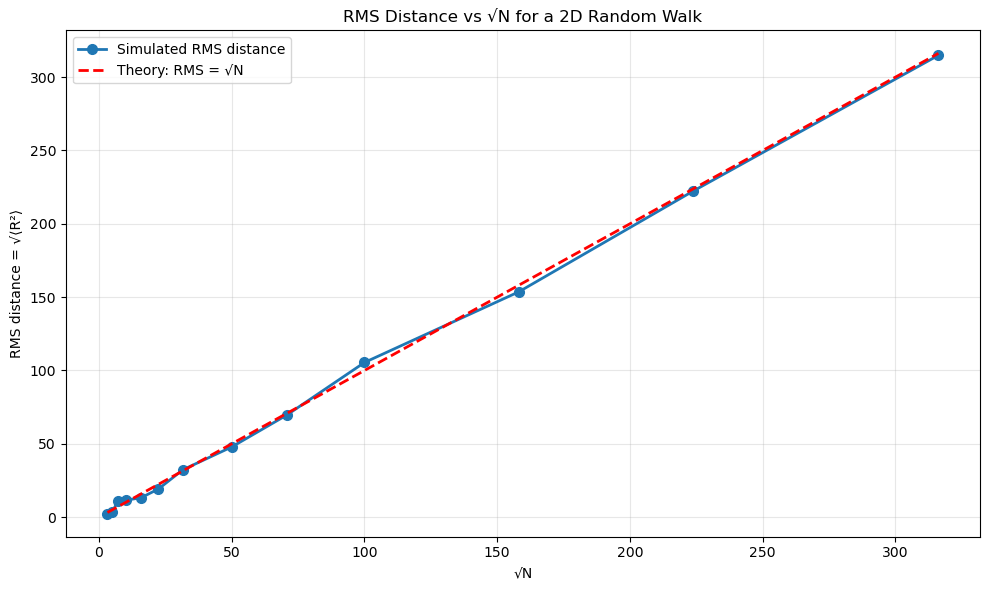


Accuracy Analysis (with K = sqrt(N) trials):
     N |   K |      √N |  RMS Distance |     Error |  Accuracy %
    10 |   3 |    3.16 |          2.33 |    0.8348 |      73.60%
    25 |   5 |    5.00 |          3.63 |    1.3741 |      72.52%
    50 |   7 |    7.07 |         10.84 |    3.7679 |      46.71%
   100 |  10 |   10.00 |         11.50 |    1.5041 |      84.96%
   250 |  15 |   15.81 |         13.21 |    2.5968 |      83.58%
   500 |  22 |   22.36 |         19.18 |    3.1771 |      85.79%
  1000 |  31 |   31.62 |         32.34 |    0.7183 |      97.73%
  2500 |  50 |   50.00 |         47.87 |    2.1296 |      95.74%
  5000 |  70 |   70.71 |         69.57 |    1.1384 |      98.39%
 10000 | 100 |  100.00 |        105.45 |    5.4538 |      94.55%
 25000 | 158 |  158.11 |        153.60 |    4.5102 |      97.15%
 50000 | 223 |  223.61 |        222.10 |    1.5037 |      99.33%
100000 | 316 |  316.23 |        314.92 |    1.3092 |      99.59%


In [70]:
import numpy as np
import matplotlib.pyplot as plt
import random

N_values = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 25000, 50000, 100000]

rms_R_values = []
std_R2_values = []
sqrt_N_values = []

random.seed() 

print("Analyzing RMS distance scaling with N")
print("=" * 70)

for N in N_values:
    K = int(np.sqrt(N))
    R2_trials = []
    
    for trial in range(K):
        x = 0.0
        y = 0.0
        
        for step in range(N):
            dx_prime = (random.random() - 0.5) * 2.0
            dy_prime = (random.random() - 0.5) * 2.0
            
            L = np.sqrt(dx_prime**2 + dy_prime**2)
            if L == 0:
                continue
            
            dx = dx_prime / L
            dy = dy_prime / L
            
            x += dx
            y += dy
        
        R2 = x**2 + y**2
        R2_trials.append(R2)
    
    R2_trials = np.array(R2_trials)
    
    mean_R2 = np.mean(R2_trials)
    rms_R = np.sqrt(mean_R2)
    
    rms_R_values.append(rms_R)
    std_R2_values.append(np.std(R2_trials))
    sqrt_N_values.append(np.sqrt(N))
    
    print(f"N = {N:>5}, K = {K:>3}, sqrt(N) = {np.sqrt(N):>7.2f}, RMS distance = {rms_R:>7.2f}")

rms_R_values = np.array(rms_R_values)
sqrt_N_values = np.array(sqrt_N_values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sqrt_N_values, rms_R_values, 'o-', linewidth=2, markersize=7, label='Simulated RMS distance')
ax.plot(sqrt_N_values, sqrt_N_values, 'r--', linewidth=2, label='Theory: RMS = √N')

ax.set_xlabel('√N')
ax.set_ylabel('RMS distance = √⟨R²⟩')
ax.set_title('RMS Distance vs √N for a 2D Random Walk')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Print accuracy analysis table
print("\nAccuracy Analysis (with K = sqrt(N) trials):")
print("=" * 110)
print(f"{'N':>6} | {'K':>3} | {'√N':>7} | {'RMS Distance':>13} | {'Error':>9} | {'Accuracy %':>11}")
print("=" * 110)
for i, N in enumerate(N_values):
    K = int(np.sqrt(N))
    theoretical = np.sqrt(N)
    observed = rms_R_values[i]
    error = abs(observed - theoretical)
    accuracy = 100.0 * (1.0 - error / theoretical)
    print(f"{N:>6} | {K:>3} | {theoretical:>7.2f} | {observed:>13.2f} | {error:>9.4f} | {accuracy:>10.2f}%")
print("=" * 110)

JC: As expected the accuracy is much higher at a larger value of N. Originally it didnt have the accuracy percentages and only the graph so it was hard to really tell the percent error. Including the table at the end was a tremendous differencem, clearly showing the accurcay increases as N greatly increases.